# FasterAI — Hands-on Model Compression Workshop

**TRAIL Factory Workshop** | June 23, 2026 · 12h00-16h00 | Le CLICK, Mons

Training a model is 1% of the journey. Shipping it — fast enough, small enough, cheap enough, on *your* hardware — is the other 99%. This workshop is about that 99%, using [FasterAI](https://github.com/FasterAI-Labs/fasterai) (compression) + FasterBench (measurement). Everything is open source.

The day is in **three parts**, each ending hands-on:

**Part 1: Measure.**

**Part 2: Compress**

**Part 3: Execute**

---

# 0. Setup

Run this cell first. It installs dependencies and downloads the dataset + pretrained model.

### Install

In [1]:
#!pip install -q fasterai==0.3.2 fastai fasterbench==0.1.0

### Import

In [2]:
from utils import *

print(f"CUDA available: {torch.cuda.is_available()}")

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


CUDA available: True


---
# PART 1: MEASURE

## First question: does a FLOP count predict speed?

In [3]:
# Two convolutions with IDENTICAL FLOPs, same GPU, same precision.
# A "fat"  : many channels, small map     B "thin": few channels, big map
A = nn.Conv2d(256, 256, 3, padding=1).cuda().eval(); xA = torch.randn(1, 256, 32,   32,   device='cuda')
B = nn.Conv2d(8,   8,   3, padding=1).cuda().eval(); xB = torch.randn(1, 8,   1024, 1024, device='cuda')
flops = 2*A.out_channels*A.kernel_size[0]*A.kernel_size[1]*xA.numel()          # == 2*8*8*9*(1024*1024): identical

with torch.no_grad():
    tA, tB = benchm(lambda: A(xA)), benchm(lambda: B(xB))

print(f"Both convs do the SAME {flops/1e9:.2f} GFLOP\n")
print(f"A  (256ch, 32x32)  : {tA*1e3:6.2f} ms")
print(f"B  (8ch, 1024x1024): {tB*1e3:6.2f} ms")
print(f"\n--> Same FLOPs, but B is {tB/tA:.1f}x slower. Same GPU, same precision.")

Both convs do the SAME 1.21 GFLOP

A  (256ch, 32x32)  :   0.04 ms
B  (8ch, 1024x1024):   0.13 ms

--> Same FLOPs, but B is 3.3x slower. Same GPU, same precision.


## Why: two forces first — compute vs memory (the roofline)

The hook showed identical FLOPs, very different speed. The classic picture that explains it is the **roofline model**. A kernel's time is the larger of two costs:

```
time ≈ max( compute_cost , memory_cost ) = max( FLOPs / peak_FLOPs , bytes / bandwidth )
```

- many channels, dense math (the *fat* conv A) → compute is the bigger cost → **compute-bound**
- little math per byte, huge activations (the *thin* conv B) → moving data is the bigger cost → **memory-bound**

The roofline plots any kernel as a single point:

- **x = arithmetic intensity**, `AI = FLOPs / bytes_moved`  (FLOP/byte)
- **y = achieved performance**, `perf = FLOPs / measured_latency`  (FLOP/s) — the "speed in FLOPS"

and draws two ceilings: a **sloped memory roof** (`y = AI × bandwidth`) and a **flat compute roof** (`y = peak FLOP/s`), meeting at the **ridge point**:

```
ridge = peak_FLOPs / bandwidth        (FLOP/byte)
```

Left of the ridge a kernel is memory-bound; right of it, compute-bound.

## The third force: overhead (what the roofline can't show)

Look at the gap between where A and B actually landed and the roofs above them — especially B, which doesn't even reach its memory roof. The roofline says it *could* go faster on bandwidth alone, so where does the rest of the time go? Into the **third force the roofline has no axis for: overhead** — Python, kernel launches, dispatch, and under-utilisation when an op is too small to fill the GPU. It dominates at **batch = 1** and with many tiny ops.

In [4]:
def many_small_ops(t):
  for _ in range(30): t = torch.tanh(t) * 1.01 + 0.001
  return t

for C in [4, 8, 16, 64, 256, 1024, 4096]:
  x = torch.randn(1, C, 32, 32, device='cuda')
  print(f"{x.numel()*30*3/1e6:.2f} FLOPs, {x.numel()*4*30*3/1e6:.2f} KiB: {benchm(lambda: many_small_ops(x))*1e3:6.3f} ms")

0.37 FLOPs, 1.47 KiB:  0.242 ms
0.74 FLOPs, 2.95 KiB:  0.241 ms
1.47 FLOPs, 5.90 KiB:  0.239 ms
5.90 FLOPs, 23.59 KiB:  0.238 ms
23.59 FLOPs, 94.37 KiB:  0.242 ms
94.37 FLOPs, 377.49 KiB:  0.368 ms
377.49 FLOPs, 1509.95 KiB:  0.737 ms


While all those operations have the exact same AI (0.25), they behave completely differently (flat, then linear). That's overhead being invisible to the roofline: the roofline has only the AI axis, AI never moved, so it would plot all five on top of each other and couldn't tell the overhead-bound small ones from the memory-bound big ones.

You have now met all three forces:
- **compute** and **memory** — the two convs, same FLOPs, different speed;
- **overhead** — the fused chain, same math, big speedup.

Each compression technique attacks one or more of these forces. But before reaching for a technique, you have to know **which force is actually slowing *your* model on *your* hardware.**

---

# HANDS-ON #1

In [5]:
# 👉 CHANGE THIS to your target model.
model = resnet18()
#model = vgg16_bn()
#model = mobilenet_v2()

model.eval();

### Compute AI for each layer

In [6]:
# 👉 CHANGE THIS to your target image size.
IMAGE_SIZE = 256

layer_ai = compute_per_layer_ai(model, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE), n=20)

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                        308,281,344       5,018,368              61.43
   1 layer1.0.conv1                               301,989,888       2,244,608             134.54
   2 layer1.0.conv2                               301,989,888       2,244,608             134.54
   3 layer1.1.conv1                               301,989,888       2,244,608             134.54
   4 layer1.1.conv2                               301,989,888       2,244,608             134.54
   5 layer2.0.conv1                               150,994,944       1,867,776              80.84
   6 layer2.0.conv2                               301,989,888       1,638,400             184.32
   7 layer2.0.downsample.0                         16,777,216       1,605,632              10.45
   8 layer2.1.conv1            

In [7]:
TARGETS = {
    "t4-colab":    dict(label="NVIDIA T4 (this Colab)", peak_TFLOPs=8.1,  bw_GBs=320),
    "a100":        dict(label="NVIDIA A100",            peak_TFLOPs=312,  bw_GBs=2039),
    "jetson-orin": dict(label="Jetson Orin",            peak_TFLOPs=275,  bw_GBs=204),
    "x86-cpu":     dict(label="x86 CPU (AVX-512/VNNI)", peak_TFLOPs=1.5,  bw_GBs=80),
    "arm-mobile":  dict(label="ARM mobile (NEON)",      peak_TFLOPs=0.5,  bw_GBs=25),
}

# 👉 CHANGE THIS to your target hardware.
TARGET = TARGETS["a100"]

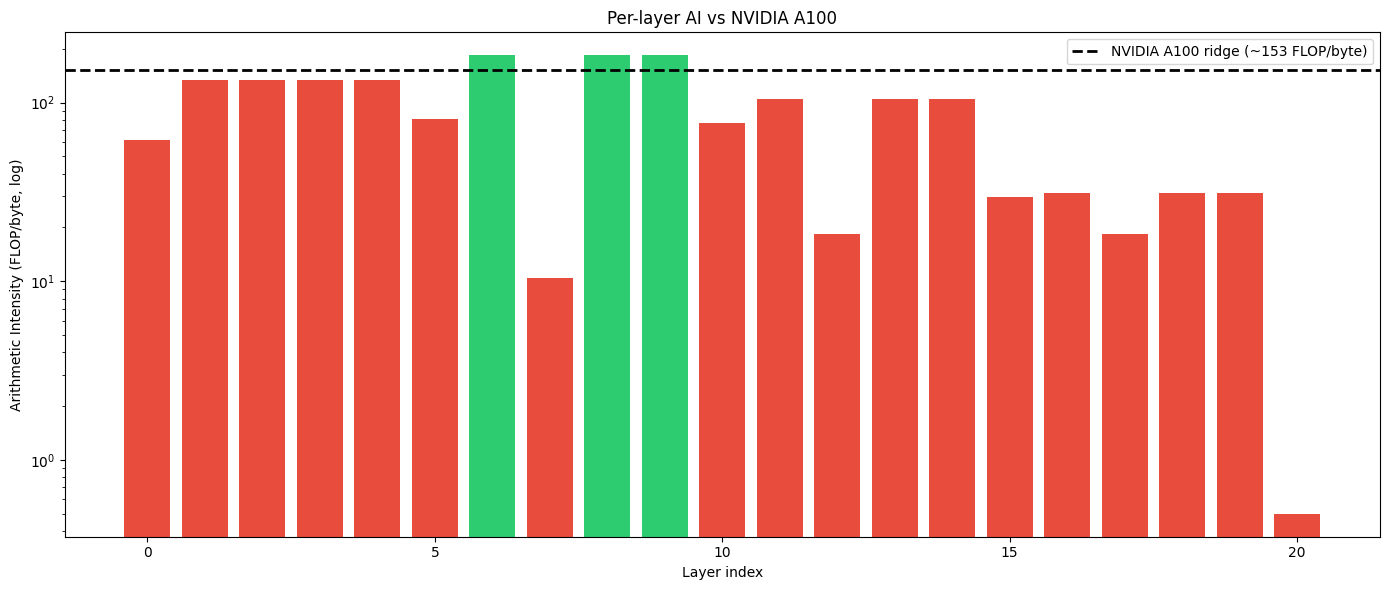

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs NVIDIA A100'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 3, 'memory_bound': 18, 'total': 21})

In [8]:
plot_ai(layer_ai, TARGET)

---

## 🔧 À tester:

1. Predict : un conv net, ses couches tombent plutôt à gauche (memory-bound) ou à droite du ridge (compute-bound) ? Plotte, compte les rouges vs verts. Tu avais raison ?
2. Change la resolution `IMAGE_SIZE`: comment cela affecte-t-il les différentes couches ?
3. Change la cible (CPU → T4 → A100) : le ridge bouge dans quel sens, combien de couches changent de couleur ? Le modèle n'a pas changé, alors qu'est-ce qui a changé ?
4. Change l'archi (resnet18 → vgg16_bn → mobilenet_v2) : laquelle est la plus memory-bound, et pourquoi ?

<br>

---
# PART 2: COMPRESS

Every model lives at a point in **accuracy (↑ better)** vs **latency / cost (← better)**. The **frontier** is the best accuracy achievable at each latency. "More efficient" = move toward the frontier, and there are only two directions:

- **Family 1 — same accuracy, lower latency** (move ←). *Keep your accuracy contract, make it cheaper.*
- **Family 2 — same latency, higher accuracy** (move ↑). *Same budget, make it better.* 

A trained model is usually **over-parameterised** — it sits to the *right* of the frontier (spends more latency than its accuracy needs). Compression moves it left.

In [9]:
model = resnet18()
model.eval();

In [10]:
IMAGE_SIZE=128

In [11]:
demo_benchmark(model, IMAGE_SIZE)

═══ Size ════════════════════════════════════
  Disk:   44.67 MiB
  Params: 11.69M
═══ Speed ═══════════════════════════════════
  cpu: 10.23 ms  │  97.8 inf/s  │  p99: 10.26 ms
═══ Compute ═════════════════════════════════
  MACs: 595.9 M


---
## Structured pruning  ·  attacks **compute + memory**

Structured pruning **removes entire channels/filters**, so tensors get physically smaller. That cuts **both** the multiply-adds (compute) *and* the bytes moved (memory) at once — so it helps whichever force was your bottleneck. The model gets smaller *and* faster on ordinary hardware, no special support needed.

In [12]:
model_pruned = copy.deepcopy(model)

prune(model_pruned, 30, IMAGE_SIZE)

demo_benchmark(model_pruned, IMAGE_SIZE)

Ignoring output layer: fc
Total ignored layers: 1
═══ Size ════════════════════════════════════
  Disk:   22.27 MiB
  Params: 5.82M
═══ Speed ═══════════════════════════════════
  cpu: 6.29 ms  │  158.9 inf/s  │  p99: 6.47 ms
═══ Compute ═════════════════════════════════
  MACs: 296.4 M


---
## INT8 quantization  ·  attacks **memory**

Quantization stores weights/activations in fewer bits (FP32 → INT8): **4× fewer bytes** to move and a ~4× smaller model, plus faster INT8 math on hardware.

In [13]:
qmodel = copy.deepcopy(model)
qmodel = quantize(qmodel)

demo_benchmark(qmodel, IMAGE_SIZE)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


═══ Size ════════════════════════════════════
  Disk:   11.29 MiB
  Params: 0
═══ Speed ═══════════════════════════════════
  cpu: 4.45 ms  │  224.5 inf/s  │  p99: 4.49 ms
═══ Compute ═════════════════════════════════
  MACs: 0.0 M


## Combine both

In [14]:
model_pruned = copy.deepcopy(model)

prune(model_pruned, 30, IMAGE_SIZE)

qmodel = quantize(model_pruned)

demo_benchmark(qmodel, IMAGE_SIZE)

Ignoring output layer: fc
Total ignored layers: 1


/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


═══ Size ════════════════════════════════════
  Disk:   5.67 MiB
  Params: 0
═══ Speed ═══════════════════════════════════
  cpu: 2.71 ms  │  369.0 inf/s  │  p99: 2.73 ms
═══ Compute ═════════════════════════════════
  MACs: 0.0 M


---
# HANDS-ON #2

In [15]:
model = resnet18()
model.eval();

In [16]:
IMAGE_SIZE = 128

layer_ai = compute_per_layer_ai(model, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                         77,070,336       1,282,816              60.08
   1 layer1.0.conv1                                75,497,472         671,744             112.39
   2 layer1.0.conv2                                75,497,472         671,744             112.39
   3 layer1.1.conv1                                75,497,472         671,744             112.39
   4 layer1.1.conv2                                75,497,472         671,744             112.39
   5 layer2.0.conv1                                37,748,736         688,128              54.86
   6 layer2.0.conv2                                75,497,472         851,968              88.62
   7 layer2.0.downsample.0                          4,194,304         425,984               9.85
   8 layer2.1.conv1            

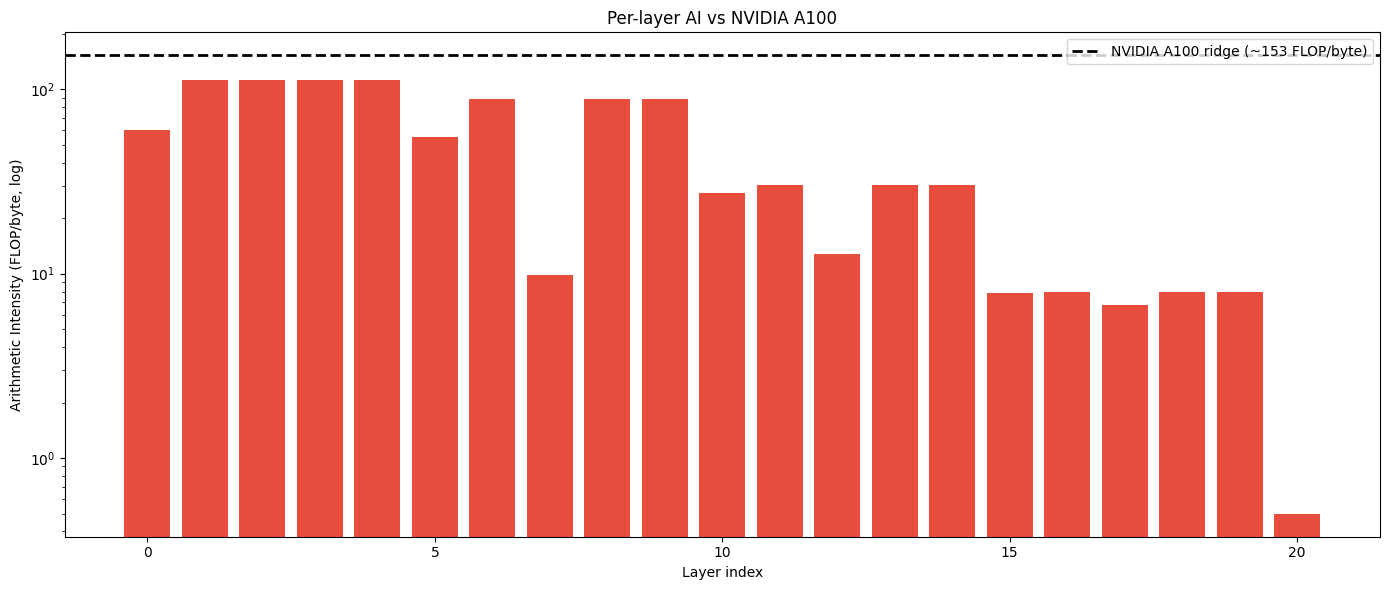

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs NVIDIA A100'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 0, 'memory_bound': 21, 'total': 21})

In [17]:
plot_ai(layer_ai, target=TARGET)

In [18]:
prof = LayerProfiler(model_pruned, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  conv1                                    Conv2d             0.153 ms (  7.2%)
  layer1.0.conv1                           Conv2d             0.126 ms (  5.9%)
  layer1.0.conv2                           Conv2d             0.121 ms (  5.7%)
  layer1.1.conv1                           Conv2d             0.119 ms (  5.6%)
  layer1.1.conv2                           Conv2d             0.119 ms (  5.6%)
  layer2.1.conv1                           Conv2d             0.106 ms (  5.0%)
  layer2.0.conv2                           Conv2d             0.105 ms (  5.0%)
  layer2.1.conv2                           Conv2d             0.105 ms (  5.0%)
  layer3.0.conv1                           Conv2d             0.093 ms (  4.4%)
  layer2.0.conv1                           Conv2d             0.090 ms (  4.3%)



### PRUNE IT

In [19]:
model_pruned = copy.deepcopy(model)
prune(model_pruned, 30, IMAGE_SIZE)

Ignoring output layer: fc
Total ignored layers: 1


In [20]:
layer_ai = compute_per_layer_ai(model_pruned, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                         52,985,856         943,376              56.17
   1 layer1.0.conv1                                35,684,352         430,144              82.96
   2 layer1.0.conv2                                35,684,352         430,144              82.96
   3 layer1.1.conv1                                35,684,352         430,144              82.96
   4 layer1.1.conv2                                35,684,352         430,144              82.96
   5 layer2.0.conv1                                18,044,928         412,336              43.76
   6 layer2.0.conv2                                36,499,968         467,428              78.09
   7 layer2.0.downsample.0                          2,004,992         287,024               6.99
   8 layer2.1.conv1            

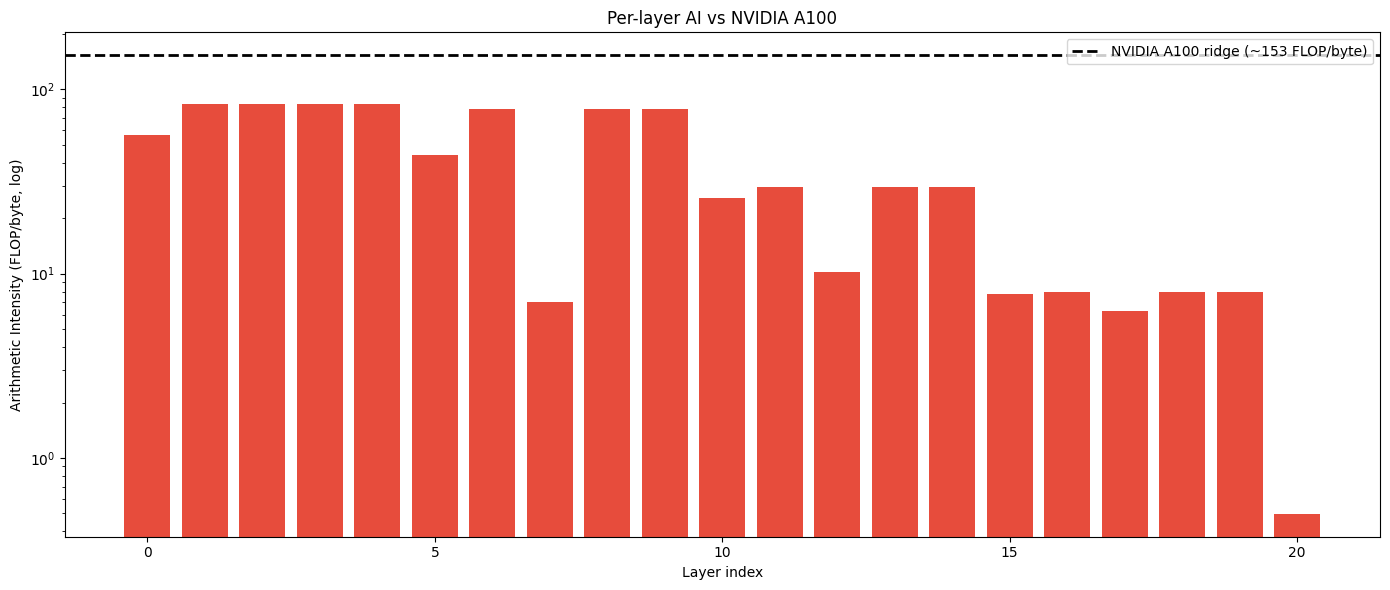

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs NVIDIA A100'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 0, 'memory_bound': 21, 'total': 21})

In [21]:
plot_ai(layer_ai,  target=TARGET)

In [22]:
prof = LayerProfiler(model_pruned, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  conv1                                    Conv2d             0.183 ms (  6.5%)
  layer1.1.conv1                           Conv2d             0.156 ms (  5.6%)
  layer1.0.conv1                           Conv2d             0.155 ms (  5.5%)
  layer1.0.conv2                           Conv2d             0.152 ms (  5.4%)
  layer1.1.conv2                           Conv2d             0.152 ms (  5.4%)
  layer2.1.conv1                           Conv2d             0.141 ms (  5.0%)
  layer2.1.conv2                           Conv2d             0.138 ms (  4.9%)
  layer2.0.conv2                           Conv2d             0.138 ms (  4.9%)
  layer3.0.conv1                           Conv2d             0.126 ms (  4.5%)
  layer2.0.conv1                           Conv2d             0.124 ms (  4.4%)



### QUANTIZE IT

In [23]:
qmodel = copy.deepcopy(model)
qmodel = quantize(qmodel)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [24]:
layer_ai = compute_per_layer_ai(qmodel, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                         77,070,336         320,704             240.32
   1 layer1.0.conv1                                75,497,472         167,936             449.56
   2 layer1.0.conv2                                75,497,472         167,936             449.56
   3 layer1.1.conv1                                75,497,472         167,936             449.56
   4 layer1.1.conv2                                75,497,472         167,936             449.56
   5 layer2.0.conv1                                37,748,736         172,032             219.43
   6 layer2.0.conv2                                75,497,472         212,992             354.46
   7 layer2.0.downsample.0                          4,194,304         106,496              39.38
   8 layer2.1.conv1            

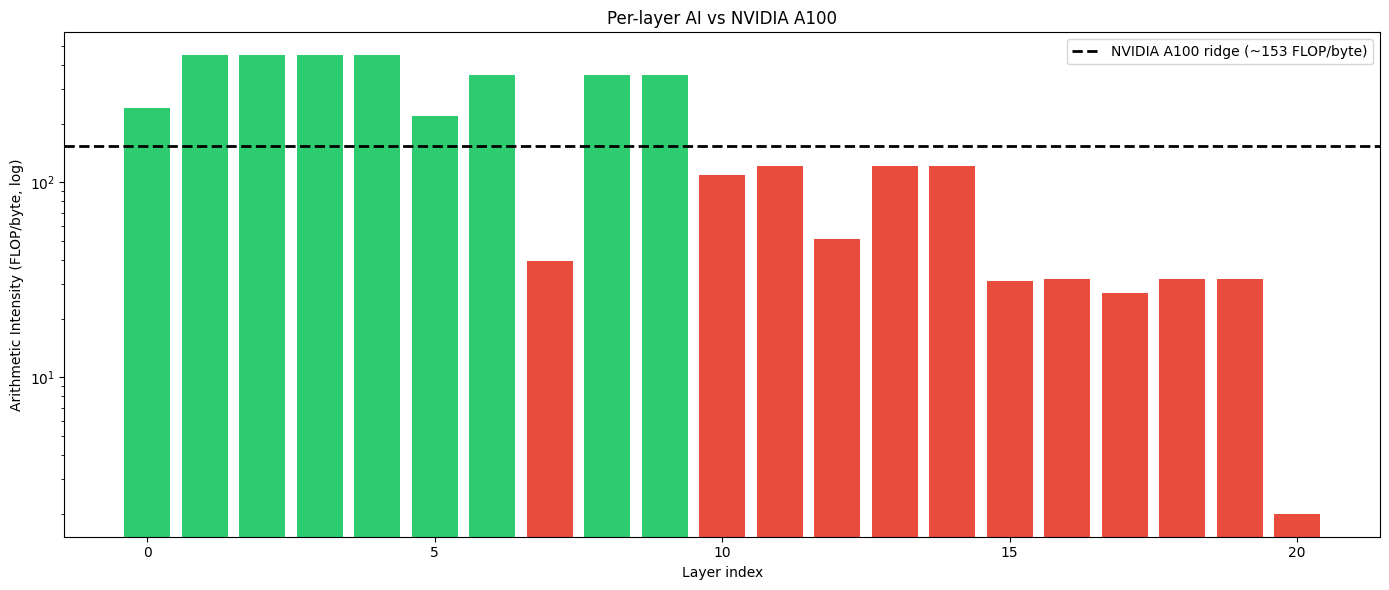

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs NVIDIA A100'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 9, 'memory_bound': 12, 'total': 21})

In [25]:
plot_ai(layer_ai, target=TARGET)

<br>

1. Predict : pruning structuré 30 % — les barres d'AI bougent ? Les MACs/latence bougent ? Run : qu'est-ce qui bouge, qu'est-ce qui ne bouge pas, pourquoi ? (les deux axes baissent ensemble → AI ≈ stable, mais le temps absolu chute)
2. Predict : quantization INT8 — les barres d'AI vont dans quel sens, jusqu'où ? Run : la taille baisse ? La latence baisse sur ce hardware ? (taille toujours ; vitesse seulement avec un datapath INT8 — CPU a VNNI, le T4 non)
3. Predict : sparsité non-structurée 50 % — l'AI bouge ? Taille ou latence bougent ? Run : pourquoi presque rien ? (pas de kernel sparse → les zéros coûtent encore compute et bytes)
4. Cross-cut : quel levier a aidé tes couches memory-bound (rouges) ? Lequel les compute-bound (vertes) ? Lequel n'a rien fait — faute du modèle ou du hardware ?
5. Meta : chaque levier est apparu sur un instrument différent (plot AI / benchmark / rien). Pourquoi ? Que voit le roofline, qu'est-ce qui lui est invisible ? (le même angle mort que l'overhead)
6. Quelles layers profitent le plus du pruning ? Et de la quantization ?

🔧 À tester : prune à 10/30/50/70 — où l'accuracy commence à tomber vs où la latence arrête de s'améliorer ? (annonce la sensibilité)

---

---
# PART 3: EXECUTE

# HANDS-ON #3

# /!\ Préentrainer 3 modèles et les mettre sur github

In [26]:
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.unfreeze()
learn.fine_tune(2)
learn.model.cpu();

torch.save(learn.model.state_dict(), 'model_weights.pth')

epoch,train_loss,valid_loss,accuracy,time
0,0.380334,0.156678,0.934371,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.144946,0.094976,0.964817,00:02
1,0.072568,0.071446,0.973613,00:02


In [27]:
def get_model(model):
    learn = vision_learner(dls, model, metrics=accuracy)
    learn.unfreeze();
    learn.model.cpu();
    learn.model.eval();
    return learn.model

In [28]:
model = get_model(resnet18)
model.load_state_dict(torch.load('model_weights.pth'))
model.eval();

In [29]:
quick_acc(model)

0.9703125

In [30]:
sens = sensitivity(model, IMAGE_SIZE)

Ignoring output layer: 1.8
Total ignored layers: 1


In [31]:
sens.summary(top=5)

════════════════════════════════════════════════════════════
Sensitivity Analysis: pruning @ 50%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.9703
  Layers analyzed: 22

  🔴 Most Sensitive (fragile):
     1. 0.0                            Δ=+0.5813  [group 0]
     2. 0.4.0.conv2                    Δ=+0.5813  [group 0]
     3. 0.4.1.conv2                    Δ=+0.5813  [group 0]
     4. 0.5.0.conv1                    Δ=+0.3109  [group 3]
     5. 1.8                            Δ=+0.2969

  🟢 Most Robust (compressible):
     1. 1.4                            Δ=+0.0031  [group 12]
     2. 0.7.0.conv1                    Δ=+0.0078  [group 9]
     3. 0.7.1.conv1                    Δ=+0.0094  [group 11]
     4. 0.6.1.conv1                    Δ=+0.0109  [group 8]
     5. 0.4.1.conv1                    Δ=+0.0297  [group 2]


In [32]:
prof = LayerProfiler(copy.deepcopy(model), torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed', device='cpu')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      Conv2d             0.204 ms (  5.2%)
  0.5.0.conv2                              Conv2d             0.195 ms (  5.0%)
  0.4.0.conv1                              Conv2d             0.192 ms (  4.9%)
  0.5.1.conv1                              Conv2d             0.186 ms (  4.7%)
  0.4.0.conv2                              Conv2d             0.186 ms (  4.7%)
  0.4.1.conv1                              Conv2d             0.185 ms (  4.7%)
  0.5.1.conv2                              Conv2d             0.184 ms (  4.7%)
  0.4.1.conv2                              Conv2d             0.183 ms (  4.6%)
  0.6.0.conv1                              Conv2d             0.168 ms (  4.2%)
  0.5.0.conv1                              Conv2d             0.158 ms (  4.0%)



In [33]:
targets = {'0.4.0.conv2': 10}

In [34]:
model_pruned = copy.deepcopy(model)
prune(model_pruned, 10, IMAGE_SIZE)

Ignoring output layer: 1.8
Total ignored layers: 1


In [35]:
quick_acc(model_pruned)

0.7828125

In [36]:
prof = LayerProfiler(model_pruned, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      Conv2d             0.216 ms (  5.9%)
  0.4.1.conv1                              Conv2d             0.194 ms (  5.3%)
  0.4.0.conv1                              Conv2d             0.188 ms (  5.1%)
  0.5.0.conv2                              Conv2d             0.179 ms (  4.9%)
  0.4.0.conv2                              Conv2d             0.179 ms (  4.9%)
  0.4.1.conv2                              Conv2d             0.177 ms (  4.8%)
  0.5.1.conv1                              Conv2d             0.176 ms (  4.8%)
  0.5.1.conv2                              Conv2d             0.175 ms (  4.8%)
  0.6.0.conv1                              Conv2d             0.161 ms (  4.4%)
  0.5.0.conv1                              Conv2d             0.148 ms (  4.0%)



In [37]:
qmodel = copy.deepcopy(model)
qmodel = quantize(qmodel)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [38]:
prof = LayerProfiler(qmodel, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      ConvReLU2d         0.116 ms (  7.4%)
  0.6.0.conv2                              Conv2d             0.094 ms (  6.0%)
  0.6.1.conv1                              ConvReLU2d         0.093 ms (  6.0%)
  0.6.1.conv2                              Conv2d             0.092 ms (  5.9%)
  0.5.1.conv1                              ConvReLU2d         0.090 ms (  5.8%)
  0.5.0.conv2                              Conv2d             0.090 ms (  5.8%)
  0.5.1.conv2                              Conv2d             0.090 ms (  5.8%)
  0.4.0.conv1                              ConvReLU2d         0.086 ms (  5.5%)
  0.4.1.conv1                              ConvReLU2d         0.086 ms (  5.5%)
  0.7.1.conv1                              ConvReLU2d         0.086 ms (  5.5%)



<eval_with_key>.28:60: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  cat = torch.cat([quantize_per_tensor_30, _1_0_ap], 1);  quantize_per_tensor_30 = _1_0_ap = None


In [39]:
quick_acc(qmodel)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/_tensor.py:1654: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  ret = func(*args, **kwargs)


0.96875

1. Predict : avant de lancer la sensibilité, quelles couches tu paries comme les plus fragiles (moins prunables) ? Run : les première/dernière couches sont-elles aussi fragiles que prévu ?
2. Croise la liste de sensibilité avec les couches les plus lentes du profiler : y a-t-il une couche à la fois lente ET robuste ? (le sweet spot — un max de vitesse pour un min d'accuracy)
3. Predict : prune uniforme 40 % vs prune guidé-par-sensibilité 40 % — même sparsité totale, lequel garde le plus d'accuracy, pourquoi ? Run les deux. (le budget par couche = tout l'enjeu → pont vers FasterRecipes)
4. Predict : après prune, tu récupères par schedule (AGP) puis QAT. Combien d'accuracy tu récupères vs le prune one-shot ? Lequel récupère le plus sur ton cas, le schedule ou le QAT ?
5. Race : le plus à gauche (rapide) au-dessus du plancher d'accuracy gagne. Ton speedup cumulé final et ton delta d'accuracy vs baseline ? Quel seul geste t'a donné le plus de vitesse-par-accuracy ?

🔧 À tester : baisse le plancher d'accuracy de 5 % — combien de vitesse en plus ça débloque ? (le contrat d'accuracy EST le bouton — c'est le pitch DPP)

<br>

---
# THE ARENA: compression competition 🏆

- **Model**: the original ResNet18 baseline (`learn.model`).
- **Goal**: the **fastest** model that still scores **≥ the accuracy floor: 95%**.
- **Rule**: accuracy below the floor = disqualified, no matter how fast.

In [40]:
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,0.370205,0.163858,0.935724,00:03


epoch,train_loss,valid_loss,accuracy,time
0,0.157366,0.133464,0.954668,00:03
1,0.099383,0.086166,0.966847,00:03
2,0.052351,0.078804,0.971583,00:03
3,0.031412,0.068124,0.977673,00:03
4,0.014964,0.072246,0.976319,00:03


In [41]:
sens = sensitivity(learn.model, IMAGE_SIZE)

Ignoring output layer: 1.8
Total ignored layers: 1


In [42]:
sens.summary(top=10)

════════════════════════════════════════════════════════════
Sensitivity Analysis: pruning @ 50%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.9797
  Layers analyzed: 22

  🔴 Most Sensitive (fragile):
     1. 0.0                            Δ=+0.6641  [group 0]
     2. 0.4.0.conv2                    Δ=+0.6641  [group 0]
     3. 0.4.1.conv2                    Δ=+0.6641  [group 0]
     4. 1.8                            Δ=+0.3063
     5. 0.5.0.conv1                    Δ=+0.2797  [group 3]
     6. 0.6.0.conv2                    Δ=+0.2234  [group 7]
     7. 0.6.0.downsample.0             Δ=+0.2234  [group 7]
     8. 0.6.1.conv2                    Δ=+0.2234  [group 7]
     9. 0.5.0.conv2                    Δ=+0.1797  [group 4]
     10. 0.5.0.downsample.0             Δ=+0.1797  [group 4]

  🟢 Most Robust (compressible):
     1. 1.4                            Δ=+0.0047  [group 12]
     2. 0.7.0.conv1                    Δ=+0.0078  [group 9]
     3. 0.7.1.con

In [43]:
prof = LayerProfiler(copy.deepcopy(learn.model), torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed', device='cpu')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      Conv2d             0.169 ms (  5.5%)
  0.4.0.conv1                              Conv2d             0.157 ms (  5.1%)
  0.5.1.conv2                              Conv2d             0.155 ms (  5.1%)
  0.5.0.conv2                              Conv2d             0.152 ms (  5.0%)
  0.5.1.conv1                              Conv2d             0.151 ms (  5.0%)
  0.4.0.conv2                              Conv2d             0.146 ms (  4.8%)
  0.4.1.conv1                              Conv2d             0.144 ms (  4.7%)
  0.4.1.conv2                              Conv2d             0.142 ms (  4.7%)
  0.6.0.conv1                              Conv2d             0.137 ms (  4.5%)
  0.5.0.conv1                              Conv2d             0.117 ms (  3.8%)



In [44]:
targets = {'0.6.1.conv1': 30,
 '0.0': 50,
 '0.4.0.conv2': 35,
 '0.4.1.conv1': 30,
 '0.4.1.conv2': 30}

In [45]:
demo_benchmark(learn.model, IMAGE_SIZE)

═══ Size ════════════════════════════════════
  Disk:   44.74 MiB
  Params: 11.70M
═══ Speed ═══════════════════════════════════
  cpu: 10.57 ms  │  94.6 inf/s  │  p99: 10.59 ms
═══ Compute ═════════════════════════════════
  MACs: 596.0 M


## 5.1 — Fine-tuning & schedules  ·  recover what pruning cost

The fastest way to give accuracy back after pruning: don't remove everything at once. **Prune gradually during training** (a schedule like AGP) so the network re-adapts as channels disappear. Same final sparsity as Part 1, far less accuracy lost.

In [46]:
targets

{'0.6.1.conv1': 30,
 '0.0': 50,
 '0.4.0.conv2': 35,
 '0.4.1.conv1': 30,
 '0.4.1.conv2': 30}

In [47]:
cbs = PruneCB(pruning_ratio=targets)

In [48]:
learn.fit(5, cbs=[cbs])

Ignoring output layer: 1.8
Total ignored layers: 1
Using per-layer pruning with 5 layer-specific ratios


epoch,train_loss,valid_loss,accuracy,time
0,0.212471,0.170429,0.924222,00:03
1,0.134380,0.170316,0.939107,00:03
2,0.121826,0.219763,0.915426,00:03
3,0.113345,0.393489,0.859946,00:03
4,0.090498,0.137633,0.949256,00:03


Pruning 5 layers to per-layer targets (epoch 0)
Pruning 5 layers to per-layer targets (epoch 1)
Pruning 5 layers to per-layer targets (epoch 2)
Pruning 5 layers to per-layer targets (epoch 3)
Pruning 5 layers to per-layer targets (epoch 4)


In [49]:
demo_benchmark(learn.model, IMAGE_SIZE)

═══ Size ════════════════════════════════════
  Disk:   42.89 MiB
  Params: 11.22M
═══ Speed ═══════════════════════════════════
  cpu: 8.44 ms  │  118.5 inf/s  │  p99: 8.45 ms
═══ Compute ═════════════════════════════════
  MACs: 455.3 M


## 5.2 — QAT  ·  recover what quantization cost

Part 1 quantized *after* training (PTQ). **Quantization-aware training** simulates INT8 rounding *during* training, so the model learns weights that survive quantization — better accuracy than PTQ at the same INT8 size.

In [50]:
learn.fit(3, cbs=[QuantizeCallback()])

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,time
0,0.069716,0.141269,0.958051,00:03
1,0.062876,0.228483,0.930988,00:03
2,0.051159,0.146368,0.953315,00:03


In [51]:
demo_benchmark(learn.model, IMAGE_SIZE)

<eval_with_key>.37:60: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  cat = torch.cat([quantize_per_tensor_30, _1_0_ap], 1);  quantize_per_tensor_30 = _1_0_ap = None


═══ Size ════════════════════════════════════
  Disk:   10.85 MiB
  Params: 3.07K
═══ Speed ═══════════════════════════════════
  cpu: 3.85 ms  │  259.9 inf/s  │  p99: 3.94 ms
═══ Compute ═════════════════════════════════
  MACs: 0.0 M


# Get Score

In [52]:
score_model(learn.model)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/_tensor.py:1654: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  ret = func(*args, **kwargs)


(4.637164754867554, 0.9484375)

<br>

---
# Wrap-up: What's next?

## The FasterAI ecosystem (open source)
- **FasterAI** (`pip install fasterai`) — pruning, sparsification, quantization, distillation, sensitivity. https://github.com/FasterAI-Labs/fasterai
- **FasterBench** (`pip install fasterbench`) — size / speed / compute / memory / energy, radar plots, per-layer profiling. https://github.com/FasterAI-Labs/fasterbench

## Coming soon: FasterRecipes
Everything you did by hand — technique, granularity, schedule, sparsity per layer, for a target — automated:

```python
from fasterrecipes import optimize, Constraints
result = optimize(model, sample, target='nvidia-a100',
                  data=dls, constraints=Constraints(min_accuracy=90))
result.summary(); result.export()
```

**14 hardware profiles** (NVIDIA A100/H100/T4/Jetson, Intel, AMD, ARM, Apple).


- **Nathan Hubens** — nh@fasterai-labs.com · https://fasterai-labs.com · https://github.com/FasterAI-Labs

---